In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df = pd.read_excel(r"C:\Users\UserName\Desktop\가천대학교\26-1학기\데이터과학\Week6_phw2_bmi_data.xlsx", sheet_name="dataset")

In [4]:
df = df[df['Sex'] == 'Male']  # 남성 데이터만 필터링
# 데이터프레임의 전체 구조 및 샘플 데이터 출력
print(df)

# 데이터셋의 통계적 요약 정보 출력 (평균, 표준편차, 최소값, 최대값, 사분위수 등)
print(df.describe())

# 데이터프레임의 메타정보 출력 (컬럼명, 결측치 개수, 데이터 타입)
print(df.info())

     Sex  Age  Height (Inches)  Weight (Pounds)  BMI
3   Male   24          66.6432          86.9820    0
7   Male   25          69.1617         120.9844    2
10  Male   19          70.7084         122.3364    2
13  Male   28          68.0356         132.2480    3
14  Male   32          69.4815         128.6789    3
15  Male   33          67.8306         113.7590    2
21  Male   30          69.2302         101.4527    0
23  Male   19          69.7075         127.7149    2
24  Male   20          68.3221         120.0835    2
26  Male   18          63.9694          84.8635    0
27  Male   31          63.7253         134.1040    3
29  Male   20          70.0981         138.9394    3
30  Male   29          66.6231         108.8550    2
32  Male   32          67.2795         132.9248    3
35  Male   31          65.0184         151.4337    4
36  Male   24          67.0044          93.7828    0
39  Male   35          66.7020         134.4490    3
40  Male   18          66.1157         117.960

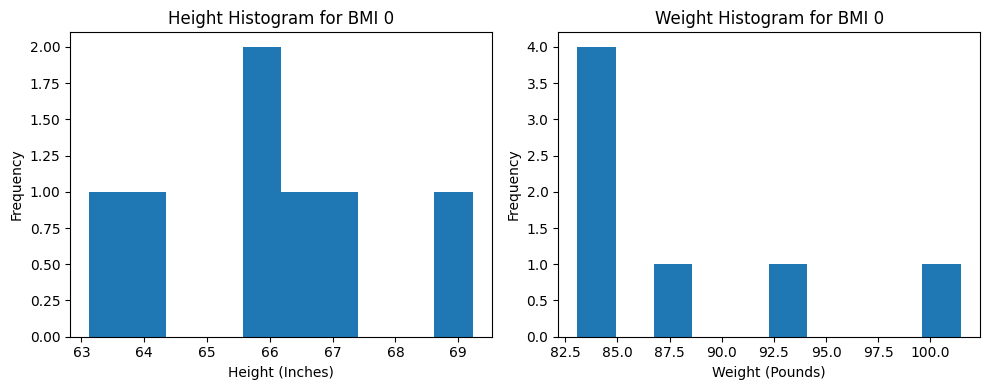

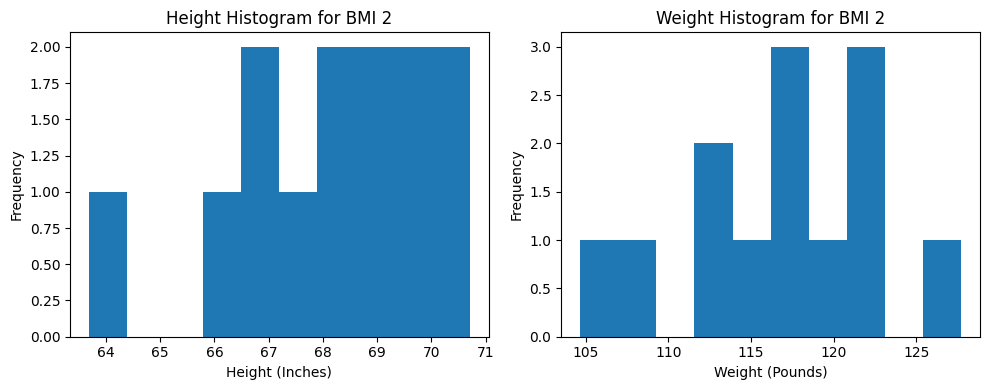

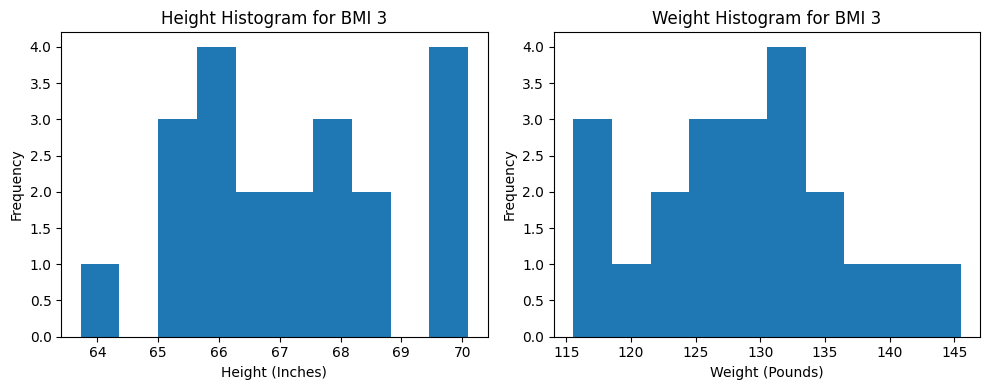

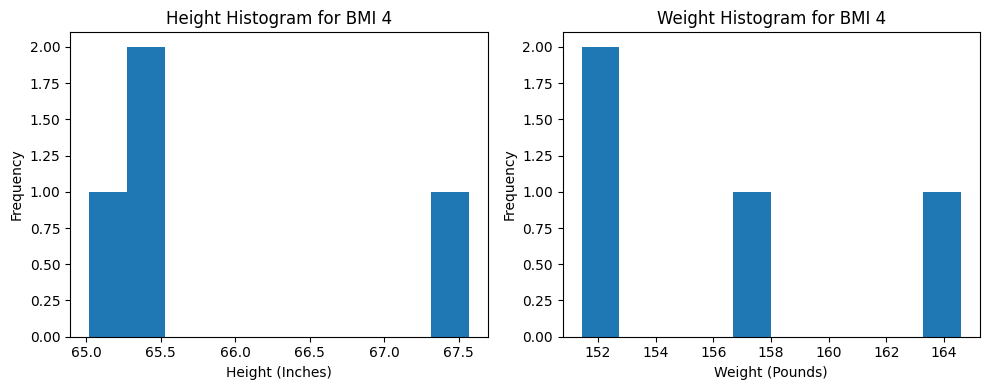

In [6]:
unique_bmis = df['BMI'].unique()
for bmi in unique_bmis:
    # 특정 BMI 값에 해당하는 데이터만 필터링
    subset = df[df['BMI'] == bmi]

    # 1행 2열의 서브플롯 생성 (키와 몸무게 히스토그램을 나란히 표시)
    plt.figure(figsize=(10, 4))

    # 왼쪽 서브플롯: 키 분포 히스토그램
    plt.subplot(1, 2, 1)
    plt.hist(subset['Height (Inches)'], bins=10)
    plt.title(f'Height Histogram for BMI {bmi}')
    plt.xlabel('Height (Inches)')
    plt.ylabel('Frequency')

    # 오른쪽 서브플롯: 몸무게 분포 히스토그램
    plt.subplot(1, 2, 2)
    plt.hist(subset['Weight (Pounds)'], bins=10)
    plt.title(f'Weight Histogram for BMI {bmi}')
    plt.xlabel('Weight (Pounds)')
    plt.ylabel('Frequency')

    # 서브플롯 간격 자동 조정
    plt.tight_layout()
    plt.show()

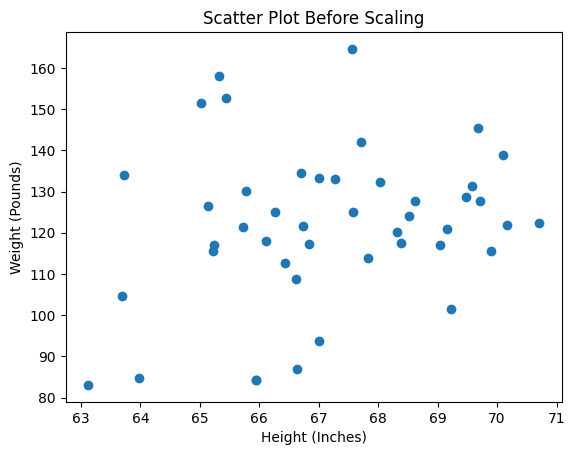

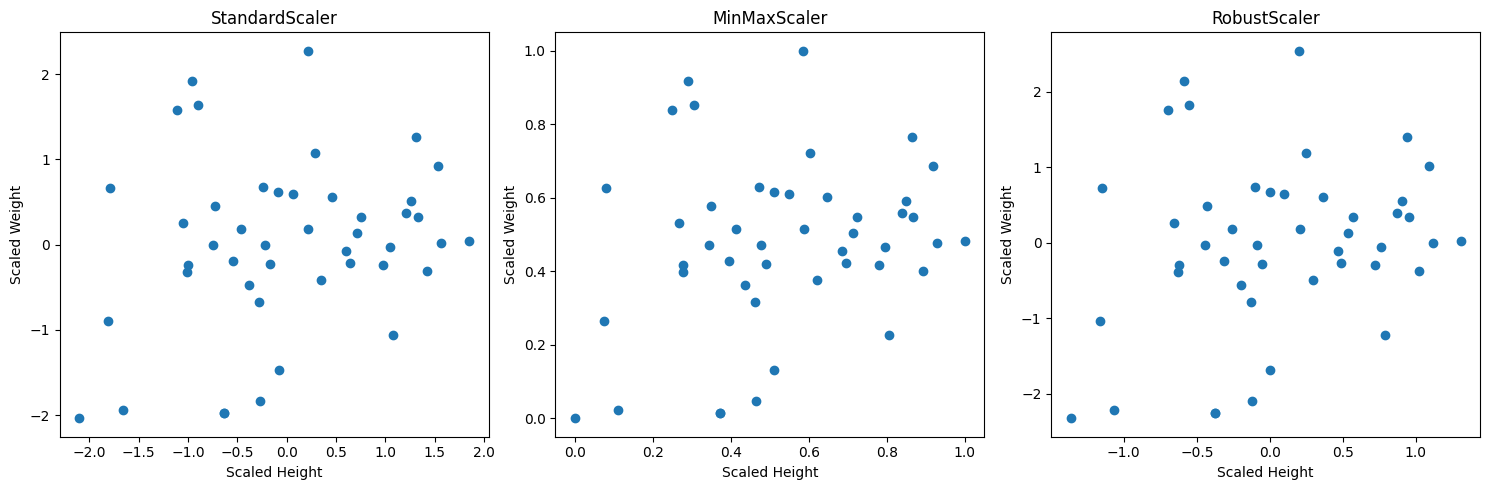

In [8]:
# 세 가지 스케일러 객체 생성:
# - StandardScaler: 평균 0, 표준편차 1로 표준화
# - MinMaxScaler: 최소값 0, 최대값 1로 정규화
# - RobustScaler: 중앙값과 IQR을 사용해 이상치에 강건한 스케일링
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}

# 스케일링 전 원본 데이터의 산점도 시각화
plt.scatter(df['Height (Inches)'], df['Weight (Pounds)'])
plt.xlabel('Height (Inches)')
plt.ylabel('Weight (Pounds)')
plt.title('Scatter Plot Before Scaling')
plt.show()

# 스케일링 후 각 방법의 결과를 비교하는 산점도 생성
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, scaler) in zip(axes, scalers.items()):
    # 키와 몸무게 데이터를 스케일링 적용
    scaled = scaler.fit_transform(df[['Height (Inches)', 'Weight (Pounds)']])

    # 스케일링된 데이터를 산점도로 표시
    ax.scatter(scaled[:, 0], scaled[:, 1])  # scaled[:, 0]은 키, scaled[:, 1]은 몸무게
    ax.set_title(f'{name}')
    ax.set_xlabel('Scaled Height')
    ax.set_ylabel('Scaled Weight')

# 서브플롯 간격 자동 조정
plt.tight_layout()
plt.show()

In [9]:
# =============================================================================
# 선형 회귀 모델 학습 및 평가
# =============================================================================

from sklearn.linear_model import LinearRegression

# 키를 독립변수로, 몸무게를 종속변수로 하는 선형 회귀 모델 학습
reg = LinearRegression().fit(df[['Height (Inches)']], df['Weight (Pounds)'])

# 모델의 결정계수(R²) 계산 - 모델의 설명력 평가 (0~1 사이 값, 1에 가까울수록 좋음)
r_sq = reg.score(df[['Height (Inches)']], df['Weight (Pounds)'])
print('coefficient of determination:', r_sq)

# 회귀식의 절편(intercept) 출력: y = ax + b에서 b에 해당
print('intercept:', reg.intercept_)

coefficient of determination: 0.05072942546818093
intercept: -27.523701852965402


In [10]:
# =============================================================================
# 잔차 계산 및 정규화
# =============================================================================

# 실제 몸무게 값들
w = df['Weight (Pounds)'].values

# 모델을 사용해 예측된 몸무게 값들
w_pred = reg.predict(df[['Height (Inches)']])

# 잔차 계산: 실제값 - 예측값 (모델의 오차)
e = w - w_pred

print(e)  # 잔차 배열 출력

[-33.4581011   -5.04737194  -7.12941493   8.71643871   1.93709577
  -9.31741238 -24.73115828   0.47132185  -4.08415964 -29.64012722
  20.14233301  10.82859667 -11.54047431  11.07196109  34.60104252
 -27.45925128  13.87834887  -1.30822526  18.31610818   0.86781552
  -9.22189614  -7.2599391   -1.748829     4.38014215 -34.5168091
  -3.66034882  34.85674887   5.52515562  11.64907252  12.06459397
   2.89924082   9.2796008  -29.54466789   3.08356837   2.56730619
  -0.4573764   42.09867286  -0.28864627  -8.76862129  19.09549363
  -6.27407242 -11.98400681  -6.80007991  40.42714059 -34.5168091 ]


In [11]:
# 잔차를 표준화: ze = (잔차 - 잔차평균) / 잔차표준편차
# 이를 통해 잔차를 평균 0, 표준편차 1인 표준정규분포로 변환
mu_e = np.mean(e)  # 잔차의 평균
sigma_e = np.std(e)  # 잔차의 표준편차
ze = (e - mu_e) / sigma_e

print(f'\nMean of residuals: {mu_e}')
print(f'Std of residuals: {sigma_e}')
print(f'\nNormalized residuals (ze) - first 10 values:\n', ze[:10])


Mean of residuals: 2.3684757858670007e-14
Std of residuals: 18.423465913351315

Normalized residuals (ze) - first 10 values:
 [-1.816059   -0.2739643  -0.38697469  0.47311612  0.10514285 -0.50573613
 -1.34237273  0.02558269 -0.22168248 -1.60882471]


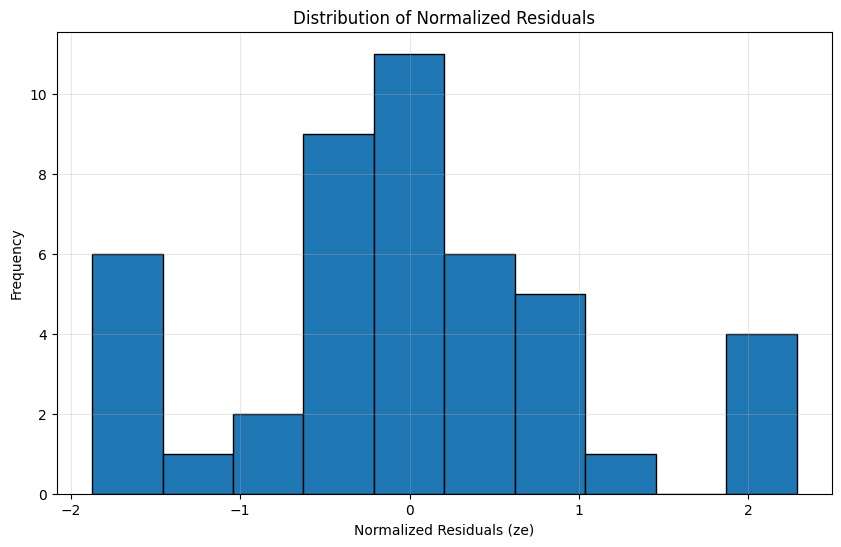

In [13]:
# =============================================================================
# 정규화된 잔차의 분포 시각화
# =============================================================================

# 정규화된 잔차의 히스토그램 생성 (이론적으로 표준정규분포를 따라야 함)
plt.figure(figsize=(10, 6))
plt.hist(ze, bins=10, edgecolor='black')
plt.xlabel('Normalized Residuals (ze)')
plt.ylabel('Frequency')
plt.title('Distribution of Normalized Residuals')
plt.grid(True, alpha=0.3)
plt.show()

In [14]:
# =============================================================================
# 이상치 기반 BMI 재분류
# =============================================================================

# 정규화된 잔차를 데이터프레임에 추가 (pandas 연산을 위해)
df['ze'] = ze

# 이상치 임계값 설정 (α = 2.0은 약 95% 신뢰구간에 해당)
alpha = 2.0

# 원본 BMI 컬럼을 복사하여 수정할 새 컬럼 생성
df['BMI_modified'] = df['BMI'].copy()

# 디버깅 정보 출력
print(f'Debug: df columns: {df.columns.tolist()}')
print(f'Debug: ze column exists: {"ze" in df.columns}')
print(f'Debug: BMI_modified column exists: {"BMI_modified" in df.columns}')
print(f'Debug: Records with ze < -alpha: {(df["ze"] < -alpha).sum()}')
print(f'Debug: Records with ze > alpha: {(df["ze"] > alpha).sum()}')

Debug: df columns: ['Sex', 'Age', 'Height (Inches)', 'Weight (Pounds)', 'BMI', 'ze', 'BMI_modified']
Debug: ze column exists: True
Debug: BMI_modified column exists: True
Debug: Records with ze < -alpha: 0
Debug: Records with ze > alpha: 2


In [17]:
# =============================================================================
# BMI 재분류 로직: 이상치 기준으로 BMI 값 수정
# =============================================================================

# 1. ze < -α (음의 이상치): 모델이 과대평가한 경우
#    실제 몸무게가 예측보다 훨씬 작음 → BMI를 0 (저체중)으로 설정
modified_count_low = 0
for idx in df.index:
    ze_val = df.loc[idx, 'ze']
    if ze_val < -alpha:
        df.loc[idx, 'BMI_modified'] = 0
        modified_count_low += 1
        if modified_count_low <= 3:  # 처음 3개 수정 사례만 출력
            print(f'Modified idx {idx}: ze={ze_val:.3f} < -{alpha}, BMI set to 0')

# 2. ze > α (양의 이상치): 모델이 과소평가한 경우
#    실제 몸무게가 예측보다 훨씬 큼 → BMI를 4 (고도비만)으로 설정
modified_count_high = 0
for idx in df.index:
    ze_val = df.loc[idx, 'ze']
    if ze_val > alpha:
        df.loc[idx, 'BMI_modified'] = 4
        modified_count_high += 1
        if modified_count_high <= 3:  # 처음 3개 수정 사례만 출력
            print(f'Modified idx {idx}: ze={ze_val:.3f} > {alpha}, BMI set to 4')

print(f'Total modifications: {modified_count_low} low, {modified_count_high} high')

# 수정 후 검증
print(f'Debug: After modification - Records with ze < -alpha: {(df["ze"] < -alpha).sum()}')
print(f'Debug: After modification - BMI_modified == 0: {(df["BMI_modified"] == 0).sum()}')

Modified idx 76: ze=2.285 > 2.0, BMI set to 4
Modified idx 94: ze=2.194 > 2.0, BMI set to 4
Total modifications: 0 low, 2 high
Debug: After modification - Records with ze < -alpha: 0
Debug: After modification - BMI_modified == 0: 7


In [18]:
# =============================================================================
# 최종 결과 출력
# =============================================================================

print(f'\nAlpha value: {alpha}')
print(f'Number of records with ze < -{alpha}: {(df["ze"] < -alpha).sum()}')
print(f'Number of records with ze > {alpha}: {(df["ze"] > alpha).sum()}')
print(f'\nOriginal BMI distribution:\n{df["BMI"].value_counts().sort_index()}')
print(f'\nModified BMI distribution:\n{df["BMI_modified"].value_counts().sort_index()}')


Alpha value: 2.0
Number of records with ze < -2.0: 0
Number of records with ze > 2.0: 2

Original BMI distribution:
BMI
0     7
2    13
3    21
4     4
Name: count, dtype: int64

Modified BMI distribution:
BMI_modified
0     7
2    13
3    21
4     4
Name: count, dtype: int64
